<a href="https://colab.research.google.com/github/amoulabensalem/ALSTM-CA/blob/main/CNN_CA_Cellular_automata_as_convolutional_neural_networks_C2_Eval2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# =====================================================================
# 1. MOUNT DRIVE & HELPER FUNCTIONS
# =====================================================================
# If running in Google Colab, uncomment the next two lines:
# from google.colab import drive
# drive.mount('/content/gdrive')

def load_tif(filepath):
    """Opens a single-band .tif file and reads it as a float32 numpy array."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Missing file: {filepath}")
    with rasterio.open(filepath) as src:
        return src.read(1).astype(np.float32)

def normalize(arr):
    min_val, max_val = np.min(arr), np.max(arr)
    if max_val == min_val: return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def invert(arr):
    return 1.0 - arr

# Helper to create X_tensor given an initial urban map and drivers
def create_X_tensor_with_seed(initial_urban_map_np, agri_drv, forest_drv, grass_drv, barren_drv, water_drv, subway_drv, highway_drv, river_drv):
    H, W = initial_urban_map_np.shape
    # These hidden channels are always just zero-filled, so they are context-independent.
    hidden_channels = [np.zeros((H, W), dtype=np.float32) for _ in range(7)]

    all_layers_np = [
        initial_urban_map_np.copy(), agri_drv, forest_drv, grass_drv, barren_drv,
        water_drv, subway_drv, highway_drv, river_drv
    ] + hidden_channels

    return torch.tensor(np.stack(all_layers_np, axis=0), dtype=torch.float32).unsqueeze(0)

# =====================================================================
# 2. DATA LOADING & ORIGINAL MAP CONSTRUCTION
# =====================================================================
print("Loading GIS Layers...")
# Seed (1990)
seed_map_1990_np = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc1.tif")

# Environmental Land Cover Drivers for 1990 (for training from 1990 to 2000)
agri_drv_1990   = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc2.tif")
forest_drv_1990 = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc3.tif")
grass_drv_1990  = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc4.tif")
barren_drv_1990 = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc6.tif")
water_drv_1990  = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_1990_lc7.tif")

# Infrastructure Drivers for 1990
subway_drv_1990  = invert(normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_sws_1990s.tif")))
highway_drv_1990 = invert(normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_ic_1990s.tif")))
river_drv_1990   = normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_water_acc.tif"))

# Environmental Land Cover Drivers for 2000 (for prediction from 2000 to 2010)
agri_drv_2000   = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc2.tif") # Assuming 2000 drivers exist
forest_drv_2000 = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc3.tif") # Assuming 2000 drivers exist
grass_drv_2000  = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc4.tif") # Assuming 2000 drivers exist
barren_drv_2000 = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc6.tif") # Assuming 2000 drivers exist
water_drv_2000  = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc7.tif") # Assuming 2000 drivers exist

# Infrastructure Drivers for 2000
subway_drv_2000  = invert(normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_sws_2000s.tif")))
highway_drv_2000 = invert(normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_ic_2000s.tif")))
river_drv_2000   = normalize(load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_water_acc.tif")) # Assuming this is static or 2000 data

# Load target map for training (2000) as numpy first
target_map_2000_np = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2000_lc1.tif")
Y_2000_full = torch.tensor(target_map_2000_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Load target map for validation (2010) as numpy first
target_map_2010_np = load_tif("/content/gdrive/MyDrive/DatasetNCA/drivers/hn_2010_lc1.tif")
Y_2010_full = torch.tensor(target_map_2010_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Construct X_full for training (using 1990 seed map and 1990 drivers)
X_train_full = create_X_tensor_with_seed(
    seed_map_1990_np, agri_drv_1990, forest_drv_1990, grass_drv_1990, barren_drv_1990,
    water_drv_1990, subway_drv_1990, highway_drv_1990, river_drv_1990
)

# Construct X_full for validation/prediction (using 2000 urban map as seed and 2000 drivers)
X_val_full = create_X_tensor_with_seed(
    target_map_2000_np, agri_drv_2000, forest_drv_2000, grass_drv_2000, barren_drv_2000,
    water_drv_2000, subway_drv_2000, highway_drv_2000, river_drv_2000
)

print(f"Full Map Base Dimensions -> X_train (1990 drivers + 1990 seed): {X_train_full.shape}, Y_2000_full: {Y_2000_full.shape}")
print(f"Full Map Base Dimensions -> X_val (2000 drivers + 2000 seed): {X_val_full.shape}, Y_2010_full: {Y_2010_full.shape}")

# =====================================================================
# 3. GEOGRAPHIC SLIDING WINDOW / PATCH GENERATION (THE BRIDGE)
# =====================================================================
class UrbanPatchDataset(Dataset):
    def __init__(self, X_tensor, Y_tensor, patch_size=16, stride=4):
        """
        Slices the massive single grid into small overlapping grids, creating
        a rich mini-batch setup following the sample-generation rule of the paper.
        """
        # Unfold extracts sliding local blocks from the grid dimensions (dims 2 and 3)
        patches_x = X_tensor.unfold(2, patch_size, stride).unfold(3, patch_size, stride)
        patches_y = Y_tensor.unfold(2, patch_size, stride).unfold(3, patch_size, stride)

        # Reshape to flatten the patch spatial coordinates into a dataset index row
        n_h, n_w = patches_x.shape[2], patches_x.shape[3]

        self.X_patches = patches_x.permute(0, 2, 3, 1, 4, 5).reshape(-1, 16, patch_size, patch_size)
        self.Y_patches = patches_y.permute(0, 2, 3, 1, 4, 5).reshape(-1, 1, patch_size, patch_size)

    def __len__(self):
        return self.X_patches.size(0)

    def __getitem__(self, idx):
        return self.X_patches[idx], self.Y_patches[idx]

# Create dataset and data loaders
train_dataset = UrbanPatchDataset(X_train_full, Y_2000_full, patch_size=16, stride=4)
val_dataset   = UrbanPatchDataset(X_val_full, Y_2010_full, patch_size=16, stride=4) # Using 2000 urban map as seed for 2010 prediction

# The paper utilizes large batch sizes (e.g., 500) because patches are small local matrices
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Successfully generated {len(train_dataset)} unique localized neighborhood training samples for 2000 target and {len(val_dataset)} for 2010 validation target.")

# =====================================================================
# 4. GILPIN CELLULAR AUTOMATA CNN ARCHITECTURE
# =====================================================================
class GilpinUrbanCA(nn.Module):
    def __init__(self, in_channels=16, hidden=100, num_1x1_layers=11):
        super().__init__()

        # Step 1: 3x3 local neighborhood convolutional filter
        # 'replicate' padding ensures geographical border cells do not crash rule calculations
        self.conv3x3 = nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1,
                                 padding_mode='replicate', bias=True)

        # Step 2: 11 deep continuous NiN (1x1) layers acting as the local MLP committee machine
        self.nin_layers = nn.ModuleList([
            nn.Conv2d(hidden, hidden, kernel_size=1, bias=True) for _ in range(num_1x1_layers)
        ])

        # Final output compression layer (linear summation)
        self.out_conv = nn.Conv2d(hidden, 1, kernel_size=1, bias=True)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        # Neighborhood grouping
        x = self.act(self.conv3x3(x))

        # Deep 1x1 cellular transitions rule network
        for nin in self.nin_layers:
            x = self.act(nin(x))

        # Omit final probability squashing function (Sigmoid) as explicitly detailed in the paper
        x = self.out_conv(x)
        return x

# =====================================================================
# 5. TRAINING ROUTINE SETUP WITH L2 LOSS
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GilpinUrbanCA(in_channels=16, hidden=100).to(device)

# The paper trains utilizing an L2 Norm Loss (MSE Loss) and an Adam optimizer with lr=1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X, Y in tqdm(loader, desc='train'):
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, Y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

def validate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, Y in tqdm(loader, desc='val'):
            X, Y = X.to(device), Y.to(device)
            pred = model(X)

            # FIX 1: Change reduction to 'mean' and scale by batch size
            # This aligns the Validation Loss scale perfectly with Train Loss
            loss = F.mse_loss(pred, Y, reduction='mean')
            total_loss += loss.item() * X.size(0)

            all_preds.append(pred.cpu())
            all_targets.append(Y.cpu())

    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    return total_loss / len(loader.dataset), preds, targets

# Example metric calculation functions handling the continuous outputs
def compute_kappa(preds, targets, threshold=0.5):
    """
    Computes the true Cohen's Kappa coefficient by flattening the
    spatial matrices and comparing the cell-by-cell classifications.
    """
    # Convert continuous model outputs to binary choices (0 or 1)
    preds_binary = (preds > threshold).numpy().astype(np.uint8).flatten()
    targets_binary = targets.numpy().astype(np.uint8).flatten()

    # Calculate the authentic Kappa score adjusted for random agreement imbalance
    return cohen_kappa_score(targets_binary, preds_binary)

def compute_fom(preds, targets, threshold=0.5):
    """
    Computes the Figure of Merit / Jaccard Index (Intersection over Union)
    specifically tracking how accurately the expanded urban footprints overlap.
    """
    preds_binary = (preds > threshold).numpy().astype(np.uint8).flatten()
    targets_binary = targets.numpy().astype(np.uint8).flatten()

    # Calculate urban overlap metrics
    intersection = np.sum((preds_binary == 1) & (targets_binary == 1))
    union = np.sum((preds_binary == 1) | (targets_binary == 1))

    if union == 0:
        return 1.0 if np.sum(targets_binary == 1) == 0 else 0.0

    return intersection / union
def compute_accuracy(preds, targets, threshold=0.5):
    """
    Computes Overall Accuracy (the percentage of correctly classified pixels
    across both urban growth and non-growth areas).
    """
    preds_binary = (preds > threshold).numpy().astype(np.uint8).flatten()
    targets_binary = targets.numpy().astype(np.uint8).flatten()

    return accuracy_score(targets_binary, preds_binary)

def compute_similarity(preds, targets, threshold=0.5):
    """
    Computes the Cosine Similarity between the predicted spatial layout
    and the target spatial layout. Returns a value between 0 (completely orthogonal/dissimilar)
    and 1 (perfectly identical spatial configuration).
    """
    preds_binary = (preds > threshold).numpy().astype(np.float32).flatten().reshape(1, -1)
    targets_binary = targets.numpy().astype(np.float32).flatten().reshape(1, -1)

    # Handle edge case where both arrays are empty/zero to avoid division by zero
    if np.sum(preds_binary) == 0 and np.sum(targets_binary) == 0:
        return 1.0

    return float(cosine_similarity(targets_binary, preds_binary)[0][0])

# =====================================================================
# 6. RUN THE TRAINING ENGINE (UPDATED WITH ACCURACY & SIMILARITY)
# =====================================================================
best_fom = -1.0
best_epoch = -1
best_kappa = 0.0
best_accuracy = 0.0
best_similarity = 0.0

ckpt_dir = './checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)
num_epochs = 80

print(f"\nStarting Core Training on device: {device}")
for epoch in range(num_epochs):
    # Train and Validate
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_preds, val_targets = validate(model, val_loader, device)

    # Calculate all spatial and classification metrics
    fom = compute_fom(val_preds, val_targets)
    kappa = compute_kappa(val_preds, val_targets)
    accuracy = compute_accuracy(val_preds, val_targets)
    similarity = compute_similarity(val_preds, val_targets)

    # Log the complete evaluation metrics matrix
    print(f"Epoch {epoch:02d} | "
          f"Train MSE: {train_loss:.6f} | "
          f"Val MSE: {val_loss:.6f} | "
          f"FoM: {fom:.4f} | "
          f"Kappa: {kappa:.4f} | "
          f"Accuracy: {accuracy:.4f} | "
          f"Similarity: {similarity:.4f}")

    # Checkpoint saving logic based on Figure of Merit
    if fom > best_fom:
        best_fom = fom
        best_epoch = epoch
        best_kappa = kappa
        best_accuracy = accuracy
        best_similarity = similarity
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict()
        }, os.path.join(ckpt_dir, f'best_fom_epoch{epoch}.pt'))

print(f"\n--- Best Metrics Achieved ---")
print(f"Epoch: {best_epoch:02d}")
print(f"Best FoM: {best_fom:.4f}")
print(f"Kappa at Best FoM: {best_kappa:.4f}")
print(f"Accuracy at Best FoM: {best_accuracy:.4f}")
print(f"Similarity at Best FoM: {best_similarity:.4f}")

Loading GIS Layers...
Full Map Base Dimensions -> X_train (1990 drivers + 1990 seed): torch.Size([1, 16, 238, 230]), Y_2000_full: torch.Size([1, 1, 238, 230])
Full Map Base Dimensions -> X_val (2000 drivers + 2000 seed): torch.Size([1, 16, 238, 230]), Y_2010_full: torch.Size([1, 1, 238, 230])
Successfully generated 3024 unique localized neighborhood training samples for 2000 target and 3024 for 2010 validation target.

Starting Core Training on device: cuda


val: 100%|██████████| 24/24 [00:00<00:00, 113.75it/s]


Epoch 00 | Train MSE: 0.154896 | Val MSE: 0.185079 | FoM: 0.0000 | Kappa: 0.0000 | Accuracy: 0.7644 | Similarity: 0.0000


val: 100%|██████████| 24/24 [00:00<00:00, 139.46it/s]


Epoch 01 | Train MSE: 0.153057 | Val MSE: 0.182260 | FoM: 0.0000 | Kappa: 0.0000 | Accuracy: 0.7644 | Similarity: 0.0000


...

Epoch 77 | Train MSE: 0.062787 | Val MSE: 0.075009 | FoM: 0.6177 | Kappa: 0.6976 | Accuracy: 0.8962 | Similarity: 0.7657


val: 100%|██████████| 24/24 [00:00<00:00, 131.87it/s]


Epoch 78 | Train MSE: 0.062588 | Val MSE: 0.075607 | FoM: 0.6112 | Kappa: 0.6930 | Accuracy: 0.8958 | Similarity: 0.7619


val: 100%|██████████| 24/24 [00:00<00:00, 129.59it/s]


Epoch 79 | Train MSE: 0.062644 | Val MSE: 0.075442 | FoM: 0.6209 | Kappa: 0.6979 | Accuracy: 0.8942 | Similarity: 0.7668

--- Best Metrics Achieved ---
Epoch: 52
Best FoM: 0.6341
Kappa at Best FoM: 0.7128
Accuracy at Best FoM: 0.9009
Similarity at Best FoM: 0.7777


In [ ]:
print(f"Best Figure of Merit (FoM) achieved: {best_fom:.4f}")

Best Figure of Merit (FoM) achieved: 0.6341


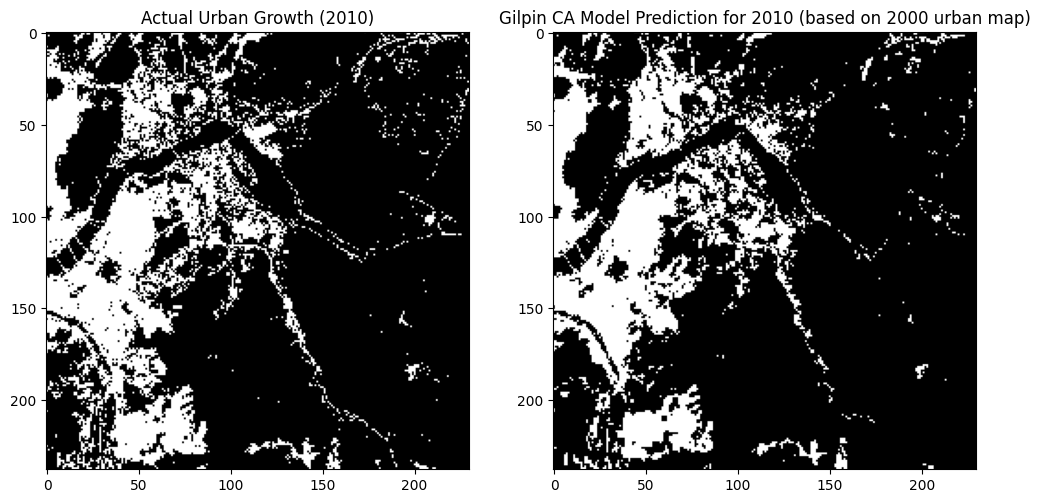

In [ ]:
model.eval()
with torch.no_grad():
    # Pass the X_val_full tensor (1990 drivers + 2000 urban map as seed) into the network
    full_prediction = model(X_val_full.to(device)).cpu() # Use X_val_full here

    # Apply your optimal evaluation threshold (0.5) to binarize it
    predicted_urban_map = (full_prediction.squeeze() > 0.5).int().numpy()

# Now you can use matplotlib to plot 'predicted_urban_map'
# side-by-side with your original 'Y_2010_full' (the real 2010 data)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(Y_2010_full.squeeze().numpy(), cmap='gray') # Use Y_2010_full here
ax[0].set_title("Actual Urban Growth (2010)") # Update title
ax[1].imshow(predicted_urban_map, cmap='gray')
ax[1].set_title("Gilpin CA Model Prediction for 2010 (based on 2000 urban map)") # Update title
plt.show()

### Visualisation des Vrais Positifs, Vrais Négatifs, Faux Positifs et Faux Négatifs

Pour une analyse plus détaillée de la performance du modèle, nous pouvons visualiser les erreurs de classification:

*   **Vrais Positifs (TP - vert)**: Zones correctement prédites comme urbaines.
*   **Vrais Négatifs (TN - noir)**: Zones correctement prédites comme non-urbaines.
*   **Faux Positifs (FP - rouge)**: Zones prédites comme urbaines, mais qui sont en réalité non-urbaines (erreur de type I).
*   **Faux Négatifs (FN - bleu)**: Zones prédites comme non-urbaines, mais qui sont en réalité urbaines (erreur de type II).

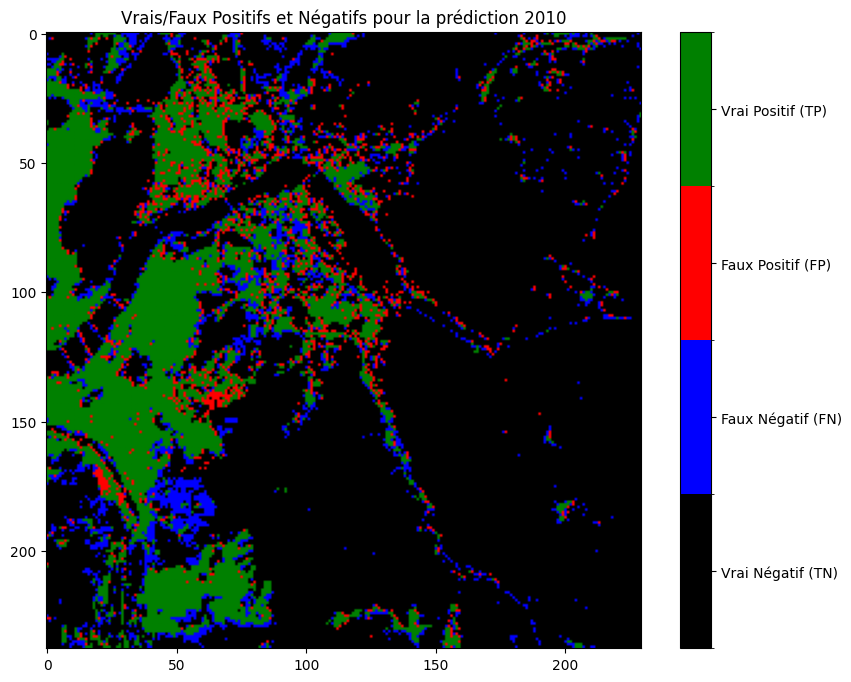

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Squeeze the target tensor to remove singleton dimensions and convert to numpy
actual_urban_map = Y_2010_full.squeeze().numpy().astype(int)

# Initialize a blank map for visualization (e.g., all black for TN initially)
# We'll use values 0=TN, 1=FN, 2=FP, 3=TP for plotting with custom colormap
visualization_map = np.zeros_like(actual_urban_map, dtype=int)

# Calculate True Positives (TP): predicted urban, actual urban (value 3)
tp_mask = (predicted_urban_map == 1) & (actual_urban_map == 1)
visualization_map[tp_mask] = 3

# Calculate False Positives (FP): predicted urban, actual non-urban (value 2)
fp_mask = (predicted_urban_map == 1) & (actual_urban_map == 0)
visualization_map[fp_mask] = 2

# Calculate False Negatives (FN): predicted non-urban, actual urban (value 1)
fn_mask = (predicted_urban_map == 0) & (actual_urban_map == 1)
visualization_map[fn_mask] = 1

# True Negatives (TN): predicted non-urban, actual non-urban (value 0, already initialized)

# Define custom colormap
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'green'])
# Define bounds for the colormap to ensure each color maps to a specific integer value
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(visualization_map, cmap=cmap, norm=norm)
ax.set_title("Vrais/Faux Positifs et Négatifs pour la prédiction 2010")

# Create a colorbar with custom labels
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['Vrai Négatif (TN)', 'Faux Négatif (FN)', 'Faux Positif (FP)', 'Vrai Positif (TP)'])

plt.show()

In [ ]:
import pandas as pd

# Calculate the counts from the masks
tp_count = np.sum(tp_mask)
fp_count = np.sum(fp_mask)
fn_count = np.sum(fn_mask)
tn_count = np.sum(~(tp_mask | fp_mask | fn_mask)) # True Negatives are pixels that are not TP, FP, or FN

# Create a DataFrame to display the confusion matrix
confusion_matrix_data = {
    'Actual Urban': [tp_count, fn_count],
    'Actual Non-Urban': [fp_count, tn_count]
}
confusion_matrix_df = pd.DataFrame(confusion_matrix_data, index=['Predicted Urban', 'Predicted Non-Urban'])

display(confusion_matrix_df)

,Actual Urban,Actual Non-Urban
Predicted Urban,9380,2292
Predicted Non-Urban,3491,39577


In [ ]:
TP = confusion_matrix_df.loc['Predicted Urban', 'Actual Urban']
FP = confusion_matrix_df.loc['Predicted Urban', 'Actual Non-Urban']
FN = confusion_matrix_df.loc['Predicted Non-Urban', 'Actual Urban']
TN = confusion_matrix_df.loc['Predicted Non-Urban', 'Actual Non-Urban']

Total = TP + FP + FN + TN

# Accuracy
accuracy_from_matrix = (TP + TN) / Total

# Precision
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Kappa (Cohen's Kappa)
Po = (TP + TN) / Total
Pe_urban = ((TP + FP) / Total) * ((TP + FN) / Total)
Pe_non_urban = ((FN + TN) / Total) * ((FP + TN) / Total)
Pe = Pe_urban + Pe_non_urban
kappa_from_matrix = (Po - Pe) / (1 - Pe) if (1 - Pe) != 0 else 0

# FoM (Figure of Merit / Jaccard Index)
fom_from_matrix = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0

print(f"Accuracy: {accuracy_from_matrix:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Kappa: {kappa_from_matrix:.4f}")
print(f"FoM (Jaccard Index): {fom_from_matrix:.4f}")

Accuracy: 0.8944
Precision: 0.8036
Kappa: 0.6965
FoM (Jaccard Index): 0.6186


In [ ]:
import pandas as pd

# Define the initial urban map (2000) for change analysis
initial_urban_map_for_change = target_map_2000_np.astype(int)

# Calculate TP, FP, FN, TN specifically for change pixels (non-urban in 2000)
# TP_growth: Actual growth (0->1) correctly predicted as growth (0->1)
tp_growth_mask = (initial_urban_map_for_change == 0) & (actual_urban_map == 1) & (predicted_urban_map == 1)

# FP_growth: Actual non-growth (0->0) but predicted as growth (0->1)
fp_growth_mask = (initial_urban_map_for_change == 0) & (actual_urban_map == 0) & (predicted_urban_map == 1)

# FN_growth: Actual growth (0->1) but predicted as non-growth (0->0)
fn_growth_mask = (initial_urban_map_for_change == 0) & (actual_urban_map == 1) & (predicted_urban_map == 0)

# TN_growth: Actual non-growth (0->0) and correctly predicted as non-growth (0->0)
tn_growth_mask = (initial_urban_map_for_change == 0) & (actual_urban_map == 0) & (predicted_urban_map == 0)

# Count the pixels for the change-focused confusion matrix
tp_growth_count = np.sum(tp_growth_mask)
fp_growth_count = np.sum(fp_growth_mask)
fn_growth_count = np.sum(fn_growth_mask)
tn_growth_count = np.sum(tn_growth_mask)

# Create a DataFrame for the change-focused confusion matrix
confusion_matrix_change_data = {
    'Actual Urban Growth': [tp_growth_count, fn_growth_count],
    'Actual No Urban Growth': [fp_growth_count, tn_growth_count]
}
confusion_matrix_change_df = pd.DataFrame(confusion_matrix_change_data,
                                         index=['Predicted Urban Growth', 'Predicted No Urban Growth'])

display(confusion_matrix_change_df)

,Actual Urban Growth,Actual No Urban Growth
Predicted Urban Growth,867,2154
Predicted No Urban Growth,1933,39522


In [ ]:
TP_growth = confusion_matrix_change_df.loc['Predicted Urban Growth', 'Actual Urban Growth']
FP_growth = confusion_matrix_change_df.loc['Predicted Urban Growth', 'Actual No Urban Growth']
FN_growth = confusion_matrix_change_df.loc['Predicted No Urban Growth', 'Actual Urban Growth']
TN_growth = confusion_matrix_change_df.loc['Predicted No Urban Growth', 'Actual No Urban Growth']

Total_growth = TP_growth + FP_growth + FN_growth + TN_growth

# Accuracy for Growth
accuracy_growth = (TP_growth + TN_growth) / Total_growth

# Precision for Growth
precision_growth = TP_growth / (TP_growth + FP_growth) if (TP_growth + FP_growth) > 0 else 0

# Kappa for Growth (Cohen's Kappa)
Po_growth = (TP_growth + TN_growth) / Total_growth
Pe_urban_growth = ((TP_growth + FP_growth) / Total_growth) * ((TP_growth + FN_growth) / Total_growth)
Pe_non_urban_growth = ((FN_growth + TN_growth) / Total_growth) * ((FP_growth + TN_growth) / Total_growth)
Pe_growth = Pe_urban_growth + Pe_non_urban_growth
kappa_growth = (Po_growth - Pe_growth) / (1 - Pe_growth) if (1 - Pe_growth) != 0 else 0

# FoM for Growth (Figure of Merit / Jaccard Index)
fom_growth = TP_growth / (TP_growth + FP_growth + FN_growth) if (TP_growth + FP_growth + FN_growth) > 0 else 0

print(f"Growth-focused Accuracy: {accuracy_growth:.4f}")
print(f"Growth-focused Precision: {precision_growth:.4f}")
print(f"Growth-focused Kappa: {kappa_growth:.4f}")
print(f"Growth-focused FoM (Jaccard Index): {fom_growth:.4f}")

Growth-focused Accuracy: 0.9081
Growth-focused Precision: 0.2870
Growth-focused Kappa: 0.2488
Growth-focused FoM (Jaccard Index): 0.1750
